# Practical No. 03: Autoencoder vs Variational Autoencoder (VAE)

## Image Reconstruction and Generation using Fashion-MNIST

**Name:** Vinay Sandip Dhake  
**PRN:** 202401110031  
**Batch:** A2  
**Subject:** Generative AI  

### Aim

To build an Autoencoder (AE) and a Variational Autoencoder (VAE) for image reconstruction and generation using the Fashion-MNIST dataset, and compare the quality of reconstructed and generated images.

## 1. Introduction

An Autoencoder is a type of neural network that learns to represent an input image in a smaller latent space and then reconstruct the original image from this representation.

A Variational Autoencoder (VAE) is a generative model that learns a probability distribution in the latent space. Unlike a traditional Autoencoder, the VAE can generate new images by sampling points from the learned latent distribution.

In this practical, both models are trained on the Fashion-MNIST dataset. The models are evaluated for:

- Image reconstruction quality
- Image generation capability
- Reconstruction loss
- Mean Squared Error (MSE)
- Peak Signal-to-Noise Ratio (PSNR)
- Latent-space representation
- Latent-space interpolation

The performance of the Autoencoder and Variational Autoencoder is then compared based on the obtained results.

## 2. Dataset Description

### Fashion-MNIST

Fashion-MNIST is a dataset of grayscale images representing different types of clothing and fashion items.

Each image has a size of **28 × 28 pixels** and belongs to one of **10 classes**.

The classes are:

1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

The dataset contains:

- **60,000 training images**
- **10,000 testing images**
- Image size: **28 × 28**
- Image type: **Grayscale**
- Number of classes: **10**

The images are normalized to the range **[0, 1]** before being given to the neural networks.

## 3. Imports and Setup

In this section, the required Python libraries are imported.

PyTorch is used to build and train the Autoencoder and Variational Autoencoder. Torchvision is used to download and load the Fashion-MNIST dataset. Matplotlib is used for visualization and NumPy is used for numerical operations.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Using device:", device)

# Hyperparameters
LATENT_DIM = 16
EPOCHS = 15
BATCH_SIZE = 128
LR = 1e-3

Using device: cpu


## 4. Load the Fashion-MNIST Dataset

The Fashion-MNIST dataset is loaded using `torchvision.datasets`.

The `ToTensor()` transformation converts the images into PyTorch tensors and scales the pixel values from the original range of 0–255 to the range 0–1.

DataLoaders are created for both the training and testing datasets.

In [3]:
# Convert images to tensors and scale pixels to [0, 1]
transform = transforms.ToTensor()

# Load Fashion-MNIST training dataset
train_data = datasets.FashionMNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

# Load Fashion-MNIST testing dataset
test_data = datasets.FashionMNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train images:", len(train_data))
print("Test images:", len(test_data))

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.8MB/s]

Train images: 60000
Test images: 10000


## 5. Sample Images from Fashion-MNIST

The following images show examples from the Fashion-MNIST dataset.

Each image is a 28 × 28 grayscale image representing a clothing or fashion item.

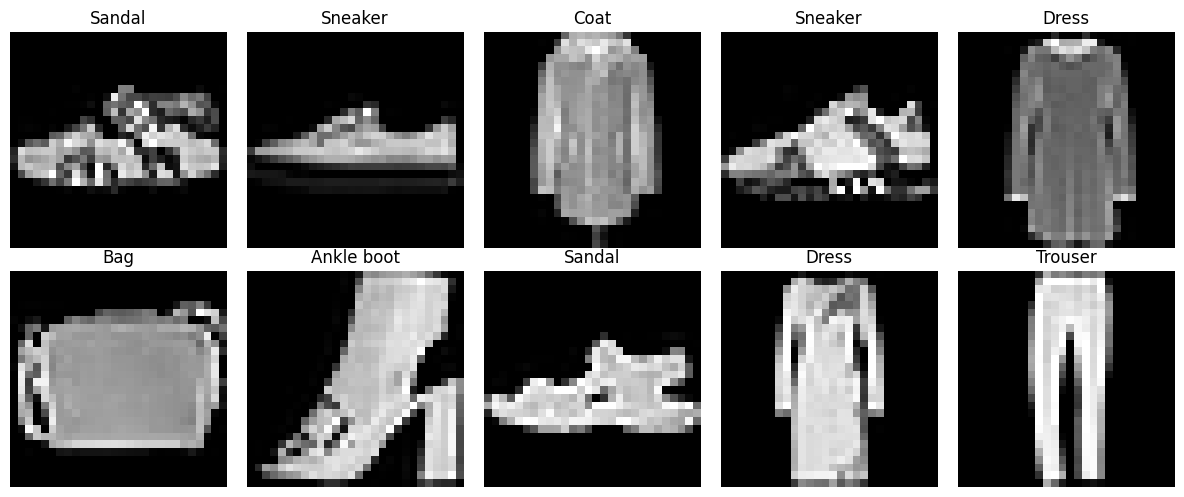

In [4]:
# Class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Get one batch of images
images, labels = next(iter(train_loader))

# Display 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Autoencoder

An Autoencoder is a neural network that learns to reconstruct its input.

It consists of two main parts:

### Encoder
The encoder compresses the input image into a lower-dimensional latent representation.

### Latent Space
The latent vector contains the important features learned from the input clothing image.

### Decoder
The decoder uses the latent representation to reconstruct the original image.

The overall process is:

**Input Image → Encoder → Latent Representation → Decoder → Reconstructed Image**

the latent dimension is set to **16**.

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode image into latent representation
        z = self.encoder(x)

        # Decode latent representation
        reconstructed = self.decoder(z)

        # Convert back to image shape
        reconstructed = reconstructed.view(-1, 1, 28, 28)

        return reconstructed


# Create Autoencoder
ae = Autoencoder().to(device)

print(ae)

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### Autoencoder Architecture

The Autoencoder uses the following architecture:

**Encoder:**

28 × 28 image  
↓  
784 input features  
↓  
256 neurons  
↓  
64 neurons  
↓  
16-dimensional latent representation

**Decoder:**

16-dimensional latent representation  
↓  
64 neurons  
↓  
256 neurons  
↓  
784 output features  
↓  
28 × 28 reconstructed image

The encoder reduces the dimensionality of the input image, while the decoder reconstructs the image from the compressed representation.

## 7. Autoencoder Loss Function

The Autoencoder is trained using reconstruction loss.

Binary Cross-Entropy (BCE) is used to measure the difference between the original image and the reconstructed image.

A lower reconstruction loss indicates that the reconstructed image is closer to the original image.

The Autoencoder loss is:

**AE Loss = Reconstruction Loss**

In [6]:
def ae_loss(recon, x):
    # Reconstruction loss
    return F.binary_cross_entropy(
        recon,
        x,
        reduction="sum"
    )

## 8. Initial Autoencoder Reconstruction

Before training, the Autoencoder has randomly initialized weights. Therefore, its reconstructed images are expected to be poor.

This step verifies that the Autoencoder can successfully perform the forward pass before training.

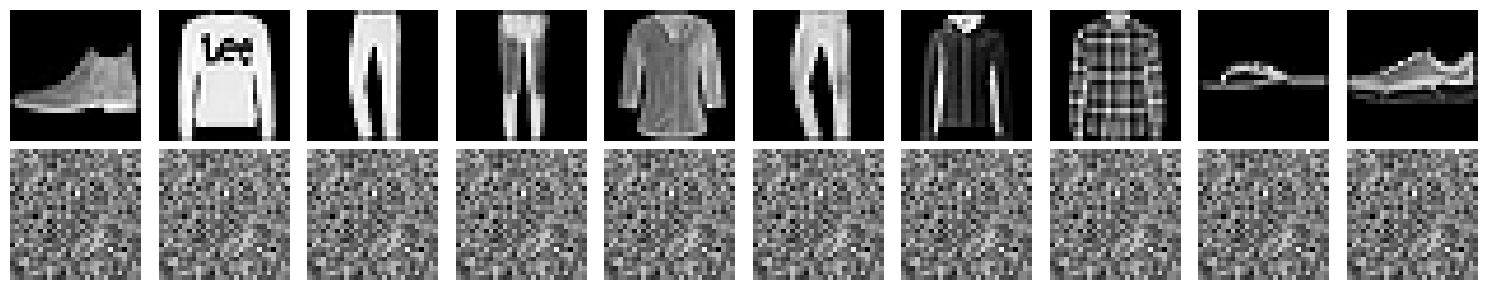

In [8]:
# Get a small batch of test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:10].to(device)

# Perform reconstruction
ae.eval()

with torch.no_grad():
    initial_recon = ae(test_images)

# Display original and reconstructed images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    # Original
    axes[0, i].imshow(
        test_images[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(
        initial_recon[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Before Training", fontsize=10)

plt.tight_layout()
plt.show()

## 9. Training the Autoencoder

The Autoencoder is trained using the Fashion-MNIST training dataset.

The **Adam optimizer** is used with a learning rate of `0.001`.

For every epoch:

1. The input clothing images are passed through the Autoencoder.
2. Reconstructed images are produced.
3. Reconstruction loss is calculated.
4. Backpropagation is performed.
5. The model weights are updated.
6. Training and testing losses are recorded.

The model is trained for **15 epochs** with a batch size of **128**.

In [9]:
def train_autoencoder(model, epochs=EPOCHS):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR
    )

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()
        train_total = 0

        for x, _ in train_loader:
            x = x.to(device)

            optimizer.zero_grad()

            # Forward pass
            recon = model(x)

            # Calculate loss
            loss = ae_loss(recon, x)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            train_total += loss.item()

        # Average training loss per image
        train_loss = train_total / len(train_data)
        train_losses.append(train_loss)

        # -------------------------
        # Testing
        # -------------------------
        model.eval()
        test_total = 0

        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)

                recon = model(x)

                loss = ae_loss(recon, x)

                test_total += loss.item()

        # Average testing loss per image
        test_loss = test_total / len(test_data)
        test_losses.append(test_loss)

        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f}"
        )

    return train_losses, test_losses

### Training the Autoencoder

The Autoencoder is now trained on the Fashion-MNIST clothing images.

The training and testing loss for each epoch are displayed below.

In [10]:
print("=== Training Autoencoder ===")

ae_train, ae_test = train_autoencoder(ae)

=== Training Autoencoder ===
Epoch  1/15 | Train Loss: 277.0761 | Test Loss: 244.5328
Epoch  2/15 | Train Loss: 238.3538 | Test Loss: 236.0706
Epoch  3/15 | Train Loss: 232.0844 | Test Loss: 231.5133
Epoch  4/15 | Train Loss: 228.4550 | Test Loss: 228.9888
Epoch  5/15 | Train Loss: 226.2456 | Test Loss: 227.1415
Epoch  6/15 | Train Loss: 224.5611 | Test Loss: 225.5016
Epoch  7/15 | Train Loss: 223.1813 | Test Loss: 224.3860
Epoch  8/15 | Train Loss: 222.1654 | Test Loss: 223.6555
Epoch  9/15 | Train Loss: 221.3293 | Test Loss: 222.7808
Epoch 10/15 | Train Loss: 220.5050 | Test Loss: 221.9998
Epoch 11/15 | Train Loss: 219.7726 | Test Loss: 221.2540
Epoch 12/15 | Train Loss: 219.1794 | Test Loss: 220.7886
Epoch 13/15 | Train Loss: 218.6742 | Test Loss: 220.3616
Epoch 14/15 | Train Loss: 218.2033 | Test Loss: 220.0282
Epoch 15/15 | Train Loss: 217.8127 | Test Loss: 219.8213


## 10. Autoencoder Loss Curves

The training and testing loss curves are plotted to observe the learning behavior of the Autoencoder.

A decreasing loss indicates that the model is improving its ability to reconstruct the input clothing images.

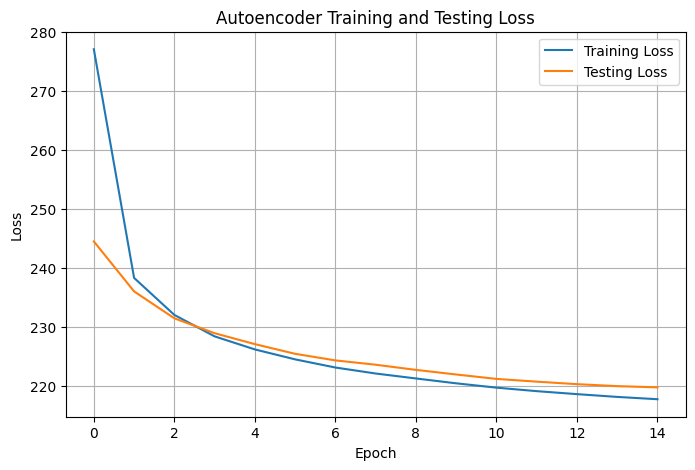

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(ae_train, label="Training Loss")
plt.plot(ae_test, label="Testing Loss")

plt.title("Autoencoder Training and Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## 11. Autoencoder Reconstruction Results

After training, the Autoencoder is used to reconstruct previously unseen Fashion-MNIST test images.

The original images are compared with their reconstructed versions to visually evaluate how well the Autoencoder has learned the important features of clothing images.

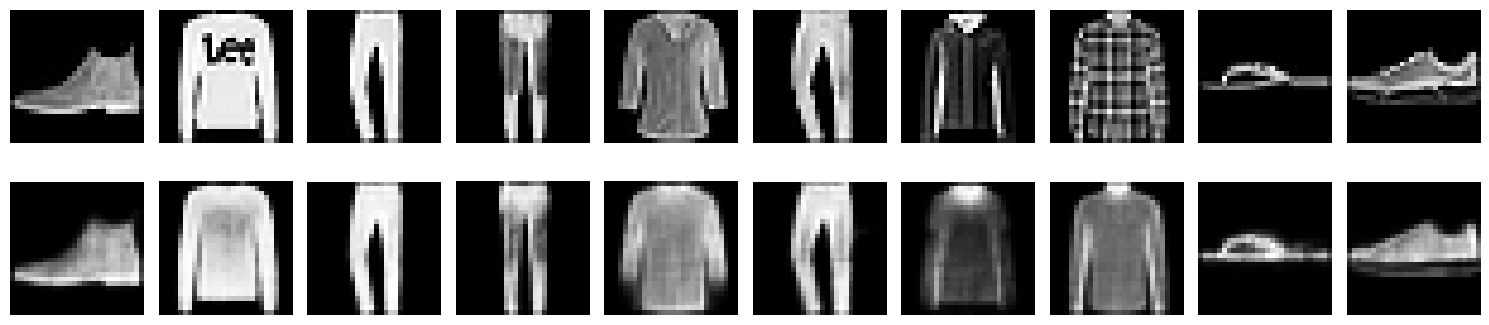

In [12]:
# Set model to evaluation mode
ae.eval()

# Get 10 test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:10].to(device)

# Reconstruct images
with torch.no_grad():
    ae_recon = ae(test_images)

# Display original and reconstructed images
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    # Original image
    axes[0, i].imshow(
        test_images[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Reconstructed image
    axes[1, i].imshow(
        ae_recon[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstructed", fontsize=11)

plt.tight_layout()
plt.show()

## 12. Quantitative Evaluation of Autoencoder Reconstruction

Visual inspection provides a qualitative comparison of the reconstructed images. To quantitatively measure reconstruction quality, we use:

### Mean Squared Error (MSE)

MSE measures the average squared difference between the original image and the reconstructed image.

A lower MSE indicates that the reconstructed image is closer to the original image.

### Peak Signal-to-Noise Ratio (PSNR)

PSNR measures the quality of the reconstructed image compared with the original image.

A higher PSNR generally indicates better reconstruction quality.

Therefore:

- **Lower MSE → Better reconstruction**
- **Higher PSNR → Better reconstruction**

In [13]:
def evaluate_autoencoder(model):
    model.eval()

    mse_total = 0

    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)

            # Reconstruct images
            recon = model(x)

            # Calculate squared error
            mse_total += F.mse_loss(
                recon,
                x,
                reduction="sum"
            ).item()

    # Mean squared error per pixel
    mse = mse_total / (len(test_data) * 784)

    # PSNR
    psnr = 10 * np.log10(1.0 / mse)

    return mse, psnr


# Evaluate Autoencoder
ae_mse, ae_psnr = evaluate_autoencoder(ae)

print("Autoencoder Performance")
print("-----------------------")
print(f"MSE  : {ae_mse:.5f}")
print(f"PSNR : {ae_psnr:.2f} dB")

Autoencoder Performance
-----------------------
MSE  : 0.01233
PSNR : 19.09 dB


### Autoencoder Quantitative Result

The trained Autoencoder is evaluated using Mean Squared Error (MSE) and Peak Signal-to-Noise Ratio (PSNR).



## 13. Variational Autoencoder (VAE)

A Variational Autoencoder (VAE) is an extension of the Autoencoder that learns a probability distribution in the latent space.

Instead of directly producing a single latent vector, the VAE encoder produces two values:

- **Mean (μ)**
- **Log-variance (log σ²)**

A latent vector is then sampled using the reparameterization trick:

**z = μ + σ × ε**

where:

- `ε` is sampled from a standard normal distribution
- `σ` is obtained from the log-variance

The decoder uses the sampled latent vector to reconstruct the input image.

The overall process is:

**Input Image → Encoder → μ and log-variance → Sampling → Latent Vector → Decoder → Reconstructed Image**

The VAE is useful for image generation because its latent space is encouraged to follow a standard normal distribution.

In [14]:
class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        # Mean of latent distribution
        self.fc_mu = nn.Linear(64, latent_dim)

        # Log variance of latent distribution
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    # Encoder function
    def encode(self, x):
        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    # Reparameterization trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)

        # Random noise from standard normal distribution
        eps = torch.randn_like(std)

        # Sample latent vector
        z = mu + eps * std

        return z

    # Decoder function
    def decode(self, z):
        reconstructed = self.decoder(z)

        return reconstructed.view(-1, 1, 28, 28)

    # Complete forward pass
    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        reconstructed = self.decode(z)

        return reconstructed, mu, logvar


# Create VAE
vae = VAE().to(device)

print(vae)

VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### VAE Architecture

The VAE uses the following architecture:

**Encoder:**

28 × 28 image  
↓  
784 input features  
↓  
256 neurons  
↓  
64 neurons  
↓  
Mean (μ) and Log-Variance (log σ²)  
↓  
16-dimensional latent representation

**Decoder:**

16-dimensional latent representation  
↓  
64 neurons  
↓  
256 neurons  
↓  
784 output features  
↓  
28 × 28 reconstructed clothing image

The main difference between the Autoencoder and VAE is that the Autoencoder maps an image to a fixed latent vector, while the VAE learns a probability distribution represented by its mean and variance.

## 14. VAE Loss Function

The VAE loss consists of two components:

### 1. Reconstruction Loss

The reconstruction loss measures the difference between the original image and the reconstructed image.

Binary Cross-Entropy (BCE) is used as the reconstruction loss.

### 2. KL Divergence Loss

The KL divergence term encourages the learned latent distribution to be close to a standard normal distribution.

This regularization makes the latent space smoother and allows new images to be generated by sampling from a standard normal distribution.

The total VAE loss is:

**VAE Loss = Reconstruction Loss + KL Divergence**

Therefore, the VAE learns both:

- To reconstruct the input clothing image
- To create a well-structured latent space suitable for generation

In [15]:
def vae_loss(recon, x, mu, logvar):

    # Reconstruction loss
    recon_loss = F.binary_cross_entropy(
        recon,
        x,
        reduction="sum"
    )

    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Total VAE loss
    total_loss = recon_loss + kl_loss

    return total_loss

## 15. VAE Forward Pass Verification

Before training the VAE, a forward pass is performed to verify that:

1. The input image is encoded.
2. Mean and log-variance are obtained.
3. A latent vector is sampled using the reparameterization trick.
4. The decoder reconstructs the image.



In [16]:
# Get a batch of test images
test_images, test_labels = next(iter(test_loader))

test_images = test_images[:10].to(device)

# Set VAE to evaluation mode
vae.eval()

# Perform forward pass
with torch.no_grad():
    vae_recon, mu, logvar = vae(test_images)

print("Input shape       :", test_images.shape)
print("Reconstruction    :", vae_recon.shape)
print("Mean (mu) shape   :", mu.shape)
print("Logvar shape      :", logvar.shape)

Input shape       : torch.Size([10, 1, 28, 28])
Reconstruction    : torch.Size([10, 1, 28, 28])
Mean (mu) shape   : torch.Size([10, 16])
Logvar shape      : torch.Size([10, 16])


## 16. Training the Variational Autoencoder

The Variational Autoencoder is trained using the Fashion-MNIST training dataset.

The Adam optimizer is used with a learning rate of `0.001`.

During training, the VAE minimizes the total loss consisting of:

- Reconstruction loss
- KL divergence loss

The reconstruction loss helps the VAE reconstruct the original clothing image, while the KL divergence regularizes the latent space toward a standard normal distribution.

The model is trained for 15 epochs with a batch size of 128.

In [17]:
def train_vae(model, epochs=EPOCHS):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR
    )

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()
        train_total = 0

        for x, _ in train_loader:
            x = x.to(device)

            optimizer.zero_grad()

            # Forward pass
            recon, mu, logvar = model(x)

            # VAE loss
            loss = vae_loss(
                recon,
                x,
                mu,
                logvar
            )

            # Backpropagation
            loss.backward()

            # Update parameters
            optimizer.step()

            train_total += loss.item()

        # Average training loss per image
        train_loss = train_total / len(train_data)
        train_losses.append(train_loss)

        # -------------------------
        # Testing
        # -------------------------
        model.eval()
        test_total = 0

        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)

                recon, mu, logvar = model(x)

                loss = vae_loss(
                    recon,
                    x,
                    mu,
                    logvar
                )

                test_total += loss.item()

        # Average testing loss per image
        test_loss = test_total / len(test_data)
        test_losses.append(test_loss)

        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f}"
        )

    return train_losses, test_losses

### Training the VAE

The VAE is now trained on the Fashion-MNIST dataset.

The training and testing losses are recorded for every epoch so that the learning behavior of the model can be analyzed.

In [18]:
print("=== Training VAE ===")

vae_train, vae_test = train_vae(vae)

=== Training VAE ===
Epoch  1/15 | Train Loss: 301.9908 | Test Loss: 268.8013
Epoch  2/15 | Train Loss: 261.1464 | Test Loss: 258.3306
Epoch  3/15 | Train Loss: 254.0115 | Test Loss: 253.3146
Epoch  4/15 | Train Loss: 249.7619 | Test Loss: 249.9090
Epoch  5/15 | Train Loss: 247.3073 | Test Loss: 248.0192
Epoch  6/15 | Train Loss: 245.8615 | Test Loss: 246.7671
Epoch  7/15 | Train Loss: 244.7372 | Test Loss: 246.1919
Epoch  8/15 | Train Loss: 243.8853 | Test Loss: 245.5546
Epoch  9/15 | Train Loss: 243.1965 | Test Loss: 244.5725
Epoch 10/15 | Train Loss: 242.6314 | Test Loss: 244.4304
Epoch 11/15 | Train Loss: 242.1656 | Test Loss: 243.8259
Epoch 12/15 | Train Loss: 241.8011 | Test Loss: 244.0618
Epoch 13/15 | Train Loss: 241.5277 | Test Loss: 243.0831
Epoch 14/15 | Train Loss: 241.2779 | Test Loss: 243.1978
Epoch 15/15 | Train Loss: 240.9702 | Test Loss: 242.6721


## 17. VAE Loss Curve

The VAE training and testing loss curves are plotted to observe the learning behavior of the model.

The total VAE loss contains both reconstruction loss and KL divergence.

A decreasing loss indicates that the model is learning to reconstruct the input images while simultaneously organizing the latent space.

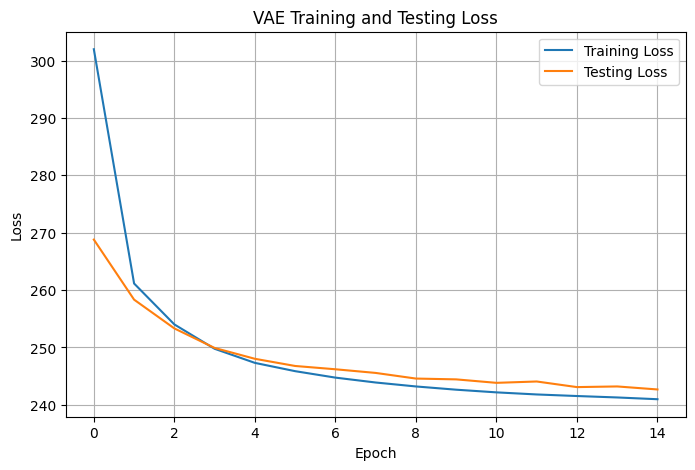

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(vae_train, label="Training Loss")
plt.plot(vae_test, label="Testing Loss")

plt.title("VAE Training and Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## 18. Autoencoder vs VAE Loss Comparison

The training losses of the Autoencoder and VAE are compared to observe their learning behavior.

The loss values should not be interpreted as directly equivalent in absolute value because the VAE loss contains both reconstruction loss and KL divergence, whereas the Autoencoder loss contains only reconstruction loss.

Therefore, the curves are mainly used to observe the training behavior of each model.

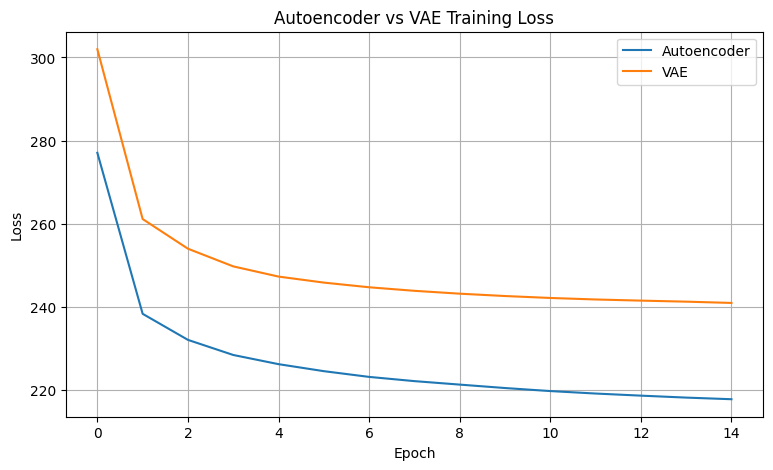

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(ae_train, label="Autoencoder")
plt.plot(vae_train, label="VAE")

plt.title("Autoencoder vs VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## 19. VAE Reconstruction Results

After training, the VAE is used to reconstruct previously unseen Fashion-MNIST test images.

The original clothing images are compared with their reconstructed versions.

The VAE may produce smoother or slightly blurrier reconstructions because the KL divergence term regularizes the latent representation.

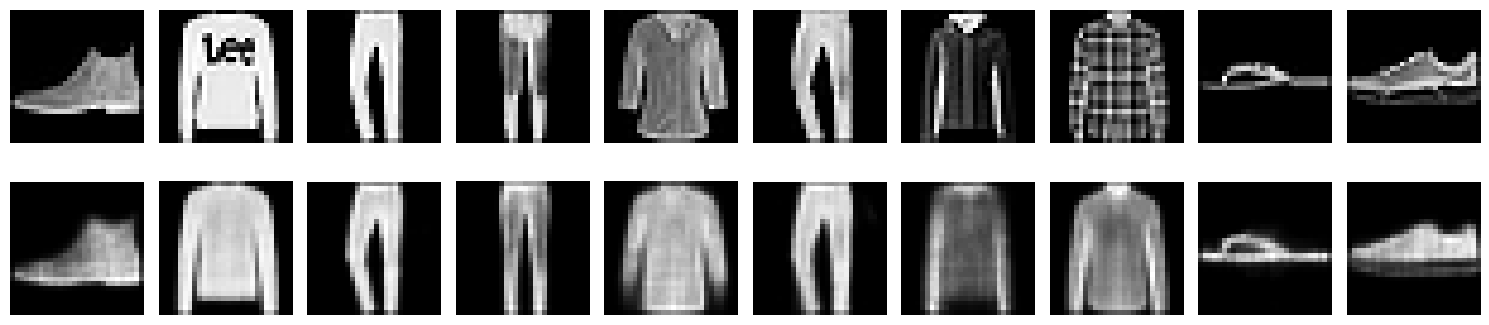

In [21]:
# Set VAE to evaluation mode
vae.eval()

# Get 10 test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:10].to(device)

# Reconstruct images
with torch.no_grad():
    vae_recon, mu, logvar = vae(test_images)

# Display original and reconstructed images
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    # Original
    axes[0, i].imshow(
        test_images[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # VAE reconstruction
    axes[1, i].imshow(
        vae_recon[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("VAE Reconstruction", fontsize=11)

plt.tight_layout()
plt.show()

## VAE Reconstruction Performance: MSE and PSNR

To quantitatively evaluate the VAE reconstruction quality, we use:

- **Mean Squared Error (MSE):** Measures the average squared difference between the original and reconstructed images. Lower MSE indicates less reconstruction error.
- **Peak Signal-to-Noise Ratio (PSNR):** Measures reconstruction quality in decibels (dB). Higher PSNR generally indicates better reconstruction quality.

These metrics will later be compared with the Autoencoder.

In [22]:
def evaluate_vae(model):
    model.eval()
    mse_total = 0

    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)

            recon, mu, logvar = model(x)

            mse_total += F.mse_loss(
                recon, x, reduction="sum"
            ).item()

    mse = mse_total / (len(test_data) * 784)

    # Pixel values are in the range [0, 1]
    psnr = 10 * np.log10(1.0 / mse)

    return mse, psnr


vae_mse, vae_psnr = evaluate_vae(vae)

print("Variational Autoencoder Performance")
print("-----------------------------------")
print(f"MSE  : {vae_mse:.5f}")
print(f"PSNR : {vae_psnr:.2f} dB")

Variational Autoencoder Performance
-----------------------------------
MSE  : 0.01682
PSNR : 17.74 dB


## 20. VAE Image Generation

One of the main advantages of a Variational Autoencoder is its ability to generate new images.

The VAE learns a continuous latent-space distribution that is approximately close to a standard normal distribution. Therefore, new latent vectors can be sampled from a standard normal distribution and passed through the decoder to generate new Fashion-MNIST-like images.

The process is:

**Random Latent Vector → VAE Decoder → Generated Image**

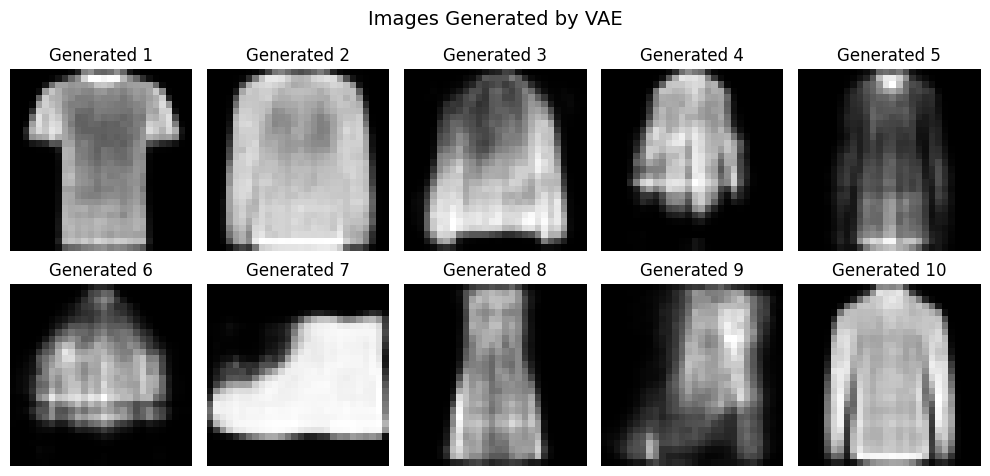

In [23]:
# Set VAE to evaluation mode
vae.eval()

# Number of images to generate
num_images = 10

# Sample random latent vectors from standard normal distribution
with torch.no_grad():
    random_latent = torch.randn(
        num_images,
        LATENT_DIM
    ).to(device)

    # Generate new images using the decoder
    generated_images = vae.decode(random_latent)

# Display generated images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        generated_images[i].cpu().squeeze(),
        cmap="gray"
    )
    ax.set_title(f"Generated {i+1}")
    ax.axis("off")

plt.suptitle("Images Generated by VAE", fontsize=14)
plt.tight_layout()
plt.show()

## 21. Latent-Space Interpolation

Latent-space interpolation demonstrates how the VAE can smoothly transition between two images.

Two images are encoded into their latent representations. Intermediate latent vectors are then generated between these two representations and passed through the decoder.

**Image A → Latent Space → Intermediate Latent Vectors → Decoder → Image B**

This shows the continuous nature of the VAE latent space.

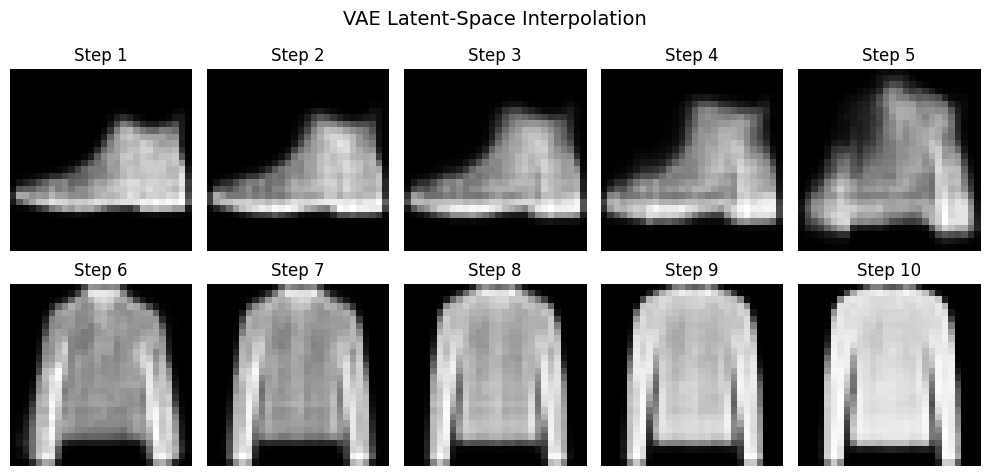

In [25]:
# Set VAE to evaluation mode
vae.eval()

# Select two images from the test dataset
img1, _ = test_data[0]
img2, _ = test_data[1]

# Add batch dimension and move to device
img1 = img1.unsqueeze(0).to(device)
img2 = img2.unsqueeze(0).to(device)

with torch.no_grad():
    # Encode both images
    mu1, logvar1 = vae.encode(img1)
    mu2, logvar2 = vae.encode(img2)

    # Use mean vectors as latent representations
    z1 = mu1
    z2 = mu2

    # Number of interpolation steps
    steps = 10

    interpolated_images = []

    for alpha in torch.linspace(0, 1, steps):
        z = (1 - alpha) * z1 + alpha * z2
        generated = vae.decode(z)
        interpolated_images.append(generated.cpu())

# Display interpolation results
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        interpolated_images[i][0].squeeze(),
        cmap="gray"
    )
    ax.set_title(f"Step {i+1}")
    ax.axis("off")

plt.suptitle("VAE Latent-Space Interpolation", fontsize=14)
plt.tight_layout()
plt.show()

## 22. Autoencoder vs Variational Autoencoder Comparison

The Autoencoder and Variational Autoencoder were evaluated using reconstruction quality metrics such as MSE and PSNR.

The results are summarized below.

## 23. Final Comparison and Observations

### Reconstruction Quality

The Autoencoder achieved a lower MSE and higher PSNR than the Variational Autoencoder:

- **AE MSE:** 0.01233
- **VAE MSE:** 0.01682
- **AE PSNR:** 19.09 dB
- **VAE PSNR:** 17.74 dB

Therefore, for this experiment, the Autoencoder produced better reconstruction quality.

### Latent Space

The Autoencoder learns a compact representation of the input images, while the VAE learns a structured and continuous latent-space distribution.

The VAE's continuous latent space allows operations such as latent-space interpolation and generation of new images.

### Image Generation

The Autoencoder primarily focuses on reconstructing input images, whereas the VAE can generate new images by sampling latent vectors and passing them through its decoder.

### Overall Observation

The Autoencoder provided better reconstruction quality in terms of MSE and PSNR in this experiment. However, the VAE provides additional generative capabilities through its probabilistic and structured latent space.

| Parameter                      | Autoencoder (AE)                | Variational Autoencoder (VAE)          |
| ------------------------------ | ------------------------------- | -------------------------------------- |
| **Latent Representation**      | Deterministic                   | Probabilistic                          |
| **Main Purpose**               | Image reconstruction            | Image reconstruction + generation      |
| **Latent Space**               | Compact representation          | Continuous and structured latent space |
| **Reconstruction MSE**         | **0.01233**                     | 0.01682                                |
| **PSNR**                       | **19.09 dB**                    | 17.74 dB                               |
| **Reconstruction Quality**     | Better in this experiment       | Lower than AE in this experiment       |
| **New Image Generation**       | Limited/not the primary purpose | **Yes**                                |
| **Latent-Space Interpolation** | Not the primary feature         | **Yes**                                |
| **Sampling from Latent Space** | Not naturally designed for it   | **Yes**                                |
| **Training Objective**         | Reconstruction loss             | Reconstruction loss + KL divergence    |


## 24. Conclusion

In this practical, an Autoencoder (AE) and a Variational Autoencoder (VAE) were implemented using the Fashion-MNIST dataset for image reconstruction and generation.

The Autoencoder achieved an MSE of **0.01233** and a PSNR of **19.09 dB**, while the Variational Autoencoder achieved an MSE of **0.01682** and a PSNR of **17.74 dB**.

The results show that the Autoencoder provided better reconstruction quality for this experiment, as indicated by its lower MSE and higher PSNR.

However, the VAE provides an important additional capability: it learns a continuous and structured latent space. This allows the VAE to generate new images by sampling latent vectors and perform smooth latent-space interpolation between different images.

Thus, the Autoencoder is effective for image reconstruction, while the Variational Autoencoder is useful for both reconstruction and generative modeling.

The practical demonstrates the difference between deterministic latent representations in Autoencoders and probabilistic, structured latent representations in Variational Autoencoders.